In [1]:
from torch import tensor, from_numpy
from torchvision import datasets, transforms
import numpy as np
import sklearn
from sklearn.model_selection import StratifiedKFold
import logging
import math
import random
from sklearn.mixture import GaussianMixture
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import kstest, anderson_ksamp, cumfreq, ks_2samp, cramervonmises, chisquare, entropy, wasserstein_distance

In [2]:
from keras.preprocessing.image import ImageDataGenerator

In [3]:
def get_data(dataset_type, path=None):
    
    if dataset_type == "MNIST":
        train, test = mnist.load_data()
    elif dataset_type == "CIFAR10":
        train, test = cifar10.load_data()
        
    train_x, train_y = from_numpy(train[0]), from_numpy(train[1])
    test_x, test_y = from_numpy(test[0]), from_numpy(test[1])
    train, test = (train_x, train_y), (test_x, test_y)
        
    return train, test

In [4]:
def log_class_counts(y_train, subset_ID_map, log=False):
    cls_counts = {}

    for subset_i, ID in subset_ID_map.items():
        unq, unq_cnt = np.unique(y_train[ID], return_counts=True)
        tmp = {unq[i]: unq_cnt[i] for i in range(len(unq))}
        cls_counts[subset_i] = tmp

    if log:
        logging.debug('Label distributions: %s' % str(cls_counts))

    return cls_counts

In [5]:
def map_to_prob(y_train, subset_map):
    counts = log_class_counts(y_train, subset_map)

    values = [np.array([counts.get(k).get(key) for key in counts.get(k)]) for k in counts]
    probs = [values[j] / values[j].sum() for j in range(len(values))]

    return probs

In [6]:
def partition_homo_skf(train, n_clients, alpha=0):
    subset_ID_map = {}
    x_train, y_train = train[0], train[1]
    # n_train = y_train.shape[0]
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=42)
    subsets = []
    for train_ID, test_ID in skf.split(train, y_train):
        subsets.append(test_ID)
    for j in range(n_clients):
        # np.random.shuffle(subsets[j])
        subset_ID_map[j] = subsets[j]
    return subset_ID_map

In [7]:
def partition_hetero_dir(train, n_clients, alpha):
    x_train, y_train = train[0], train[1]
    
    min_size = 0
    # classes
    K = len(y_train.unique())
    # data points
    N = y_train.shape[0]
    subset_ID_map = {}

    while min_size < 10:
        subset_ID_list = [[] for _ in range(n_clients)]
        for k in range(K):
            ids_k = np.where(y_train == k)[0]
            np.random.shuffle(ids_k)
            proportions = np.random.dirichlet(np.repeat(alpha, n_clients))
            proportions = np.array(
                [p * (len(ids_j) < N / n_clients) for p, ids_j in zip(proportions, subset_ID_list)])
            proportions = proportions / proportions.sum()
            proportions = (np.cumsum(proportions) * len(ids_k)).astype(int)[:-1]
            subset_ID_list = [ids_j + ids.tolist() for ids_j, ids in
                              zip(subset_ID_list, np.split(ids_k, proportions))]
            min_size = min([len(ids_j) for ids_j in subset_ID_list])

    for j in range(n_clients):
        np.random.shuffle(subset_ID_list[j])
        subset_ID_map[j] = subset_ID_list[j]

    return subset_ID_map

In [8]:
def partition_hetero_gaussian(train, n_clients, alpha, bootstrap=False):
    x_train, y_train = train[0], train[1]
    min_size = 0
    # classes
    K = len(set(y_train.tolist()))
    # data points
    N = y_train.shape[0]
    subset_ID_map = {}

    def gaussian_pdf(x, mu, sig):
        return np.exp(- np.power(x - mu, 2.) / (2 * np.power(sig, 2.))) / (sig * math.sqrt(2 * math.pi))

    labels = list(set(y_train.tolist()))
    mu = 5
    sig = alpha
    proportions = np.array([gaussian_pdf(x, mu, sig) for x in labels])

    if bootstrap:
        # make sure the most frequent label always gets selected
        norm_const = 1 / max(proportions)
        proportions = [item * norm_const for item in proportions]
        prob_map = {labels[i]: proportions[i] for i in range(len(labels))}

        def shuffle_labels(map):
            max_item = max(map, key=map.get)
            max_val = map.get(max_item)
            del map[max_item]
            keys = list(map.keys())
            values = list(map.values())
            random.shuffle(values)
            new_map = {keys[i]: values[i] for i in range(len(keys))}
            new_map.update({max_item:max_val})
            return new_map

        prob_map = shuffle_labels(prob_map)

        subset_ID_list = [[] for _ in range(n_clients)]

        for k in range(K):
            sample = []

            for ID, x in enumerate(y_train.tolist):
                if random.uniform(0, 1) < float(prob_map.get(x)):
                    sample.append(ID)

            subset_ID_list[k] = sample

    else:
        while min_size < 10:
            subset_ID_list = [[] for _ in range(n_clients)]
            for k in range(K):
                ids_k = np.where(y_train == k)[0]
                np.random.shuffle(ids_k)
                proportions = np.array([gaussian_pdf(x, mu, sig) for x in labels])
                proportions = np.array(
                    [p * (len(ids_j) < N / n_clients) for p, ids_j in zip(proportions, subset_ID_list)])
                if proportions.sum()!=0:
                    proportions = proportions / proportions.sum()
                proportions = (np.cumsum(proportions) * len(ids_k)).astype(int)[:-1]
                subset_ID_list = [ids_j + ids.tolist() for ids_j, ids in
                                  zip(subset_ID_list, np.split(ids_k, proportions))]
                min_size = min([len(ids_j) for ids_j in subset_ID_list])

    subset_ID_map = {i: subset_ID_list[i] for i in range(n_clients)}

    return subset_ID_map

In [9]:
def partition_quantity_based(train, n_clients, alpha):
    # sorted = pd.concat([y for x, y in data.groupby(0)]).reset_index().drop(columns=['index'])
    x, y = train[0], train[1]    
    K = len(y.unique())
    # subsets_pure = {i: np.where(y == i)[0] for i in range(10)}
    subsets_pure = np.concatenate([np.where(y == i)[0] for i in range(K)])

    ids = np.arange(y.shape[0])
    batch_ids = np.array_split(ids, n_clients*alpha)
    minibatches = []

    for i in range(n_clients*alpha):
        batch_i = [subsets_pure[j] for j in batch_ids[i]]
        minibatches.append(batch_i)

    minibatches = np.array(minibatches)

    ids_mini = np.random.permutation(range(n_clients*alpha))
    subset_indices = np.array_split(ids_mini, n_clients)

    clients = {}

    for index in subset_indices:
        client_i = []
        for i in index:
            client_i.append(minibatches[i])
        client_i = np.concatenate(client_i)
        clients.update({i:np.array(client_i)})

    return clients


In [10]:
def quantity_efficient(path, n_clients, alpha):
    data = datasets.MNIST(root=path, train=True, download=True, transform=None)
    x, y = data.data, data.targets.numpy()
    K = len(set(y.tolist()))
    ids = np.arange(y.shape[0])
    subsets_pure = np.concatenate([np.where(y == i)[0] for i in range(K)])
    minibatches = np.array_split(subsets_pure, n_clients * alpha)
    clients = {i: np.concatenate(minibatches[i::n_clients]) for i in range(n_clients)}
    return clients

In [11]:
def partition(dataset_type, type, n_clients, alpha):
    train, test = get_data(dataset_type, "D:/datasets")
    
    partition_funcs = {
        "homo" : partition_homo_skf,
        "hetero-dir": partition_hetero_dir,
        "hetero-gaussian": partition_hetero_gaussian,
        "quant": partition_quantity_based
    }
    
    try:
        partition_func = partition_funcs[type]
    except KeyError:
        raise ValueError(f"Invalid mode: {type}")

    return partition_func(train, n_clients, alpha)

In [12]:
def vis_datasets(path, epoch, y_train, subset_ID_map, mode_plot, mode_partitioning, alpha, save=False):
    counts = log_class_counts(y_train, subset_ID_map)

    values = [np.array([counts.get(k).get(key) for key in counts.get(k)]) for k in counts]
    values_normalized = [values[j] / values[j].sum() for j in range(len(values))]

    n_clients = len(subset_ID_map)

    title_formats = {
        "hetero-dir": "A distribution-based heterogeneous partitioning X~Dir({alpha}) with {n_clients} subsets",
        "hetero-gaussian": "A distribution-based Gaussian heterogeneous partitioning σ={alpha} with {n_clients} subsets",
        "homo": "A homogeneous partitioning with {n_clients} subsets",
    }
    main_title = title_formats.get(mode_partitioning, "")
    main_title = main_title.format(alpha=alpha, n_clients=n_clients)

    subtitle_formats = {
        "hetero_dir": "α_{epoch}={alpha}",
        "hetero-gaussian": "σ_{epoch}={alpha}",
        "homo" : ""
    }

    subtitle = subtitle_formats.get(mode_partitioning, "")
    subtitle = subtitle.format(epoch=epoch, alpha=alpha)

    if mode_plot == "heatmap":
        ax = sns.heatmap(pd.DataFrame(values_normalized), vmin=0, vmax=1, cmap=sns.cm.rocket_r)
        ax.set(xlabel="Labels", ylabel="Clients", title=main_title)
        plt.show()
    elif mode_plot == "histogram":
        dim_x = 2
        dim_y = 5
        K = len(set(y_train.tolist()))
        fig, axes = plt.subplots(dim_y, dim_x)
        # TODO: orient hard-coded values around 'K'
        for j in range(len(values)):
            plt.figure(figsize=(5, 3), dpi=300)
            plt.hist(values[j], [(i - 0.5) / 2 for i in range(2*K)], label="Sampled dist")
            x = np.arange(-0.5, 9.5, 0.1)
            plt.xticks([i for i in range(K)])
            plt.xlabel("Label")
            plt.xlim([-1, 10])
            plt.ylabel("Entries")
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.show()

In [13]:
def tensor_to_csv(x_train, y_train, subset_map, epoch_num):
    for key in subset_map:
        x, y = x_train[subset_map.get(key)], y_train[subset_map.get(key)]
        df_x = pd.DataFrame(x.tolist())
        df_y = pd.DataFrame(y.tolist())
        df_x['targets'] = df_y
        df_x.rename(columns={0: 'data', "targets": "targets"})
        df_x.to_csv(f'subsets/epoch_{epoch_num}_subset_{key + 1}.csv', index=False)

In [14]:
def getDivs(N):
    factors = {1}
    maxP  = int(N**0.5)
    p,inc = 2,1
    while p <= maxP:
        while N%p==0:
            factors.update([f*p for f in factors])
            N //= p
            maxP = int(N**0.5)
        p,inc = p+inc,2
    if N>1:
        factors.update([f*N for f in factors])
    return sorted(factors)  

In [50]:
import tensorflow as tf
from keras import models, layers, optimizers
from keras.datasets import mnist, cifar10
from keras.layers import Input, Lambda
from keras.layers.preprocessing.normalization import Normalization
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.utils import to_categorical, plot_model
from keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
# from ann_visualizer.visualize import ann_viz

ModuleNotFoundError: No module named 'ann_visualizer'

In [47]:
def get_layers_functions(dataset_type, model_type):
    cnn_layers = {
        "MNIST": [Conv2D(filters=64,
                         kernel_size=3,
                         activation='relu',
                         input_shape=(28, 28, 1)),
                  MaxPooling2D(2),
                  Conv2D(filters=64,
                         kernel_size=3,
                         activation='relu'),
                  MaxPooling2D(2),
                  Conv2D(filters=64,
                         kernel_size=3,
                         activation='relu'),
                  Flatten(),
                  Dropout(0.2),
                  Dense(10, activation='softmax')
                  ],
        "CIFAR10": [Conv2D(32, (3, 3),
                           activation='relu',
                           input_shape=(32, 32, 3)),
                    MaxPooling2D((2, 2)),
                    Conv2D(64, (3, 3),
                           activation='relu'),
                    MaxPooling2D((2, 2)),
                    Conv2D(64, (3, 3),
                           activation='relu'),
                    Flatten(),
                    Dense(64, activation='relu'),
                    Dense(10)]
    }

    cnn_loss = {
        "MNIST": CategoricalCrossentropy(),
        "CIFAR10": CategoricalCrossentropy()
    }

    # TODO: Find best configuration for CIFAR10
    nn_layers = {
        "MNIST": [
            Flatten(input_shape=(28, 28)),
            Dense(256, activation='relu'),
            Dense(128, activation='relu'),
            Dropout(rate=0.4),
            Dense(units=10, activation='softmax')
        ],
        "CIFAR10": [
            Flatten(input_shape=(32, 32)),
            Dense(256, activation='relu'),
            Dense(128, activation='relu'),
            Dropout(rate=0.4),
            Dense(units=10, activation='softmax')
        ]
    }

    nn_loss = {
        "MNIST": CategoricalCrossentropy(),
        "CIFAR10": CategoricalCrossentropy()
    }

    if model_type == "nn":
        return nn_layers.get(dataset_type), nn_loss.get(dataset_type)
    elif model_type == "cnn":
        return cnn_layers.get(dataset_type), cnn_loss.get(dataset_type)
    else:
        raise ValueError(f"Invalid mode: {model_type}")

In [55]:
def build_model(dataset_type, model_type, data, n_epochs, lrate, batch_size=None):
    train_data, train_targets, test_data, test_targets = data
    
    layers, loss_function = get_layers_functions(dataset_type, model_type)
    
    model = Sequential()
    
    for layer in layers:
        model.add(layer)
        
    model.compile(loss=loss_function,
                  optimizer=optimizers.Adam(learning_rate=lrate),
                  metrics=['accuracy'])
    
    # TODO: batch_size --> SGD
    # 60000/32 = 1875 datapoints per epoch
    history = model.fit(train_data, train_targets,
                        epochs=n_epochs,
                        validation_data=(test_data, test_targets), batch_size=32)
    # batch_size=4000
    loss, accuracy = model.evaluate(test_data, test_targets, batch_size=batch_size)
    
    return accuracy, loss, history.epoch, pd.DataFrame(history.history)

In [18]:
def plot_curve(epochs, hist, list_of_metrics):
  plt.figure()
  plt.xlabel("Epoch")
  plt.ylabel("Value")

  for m in list_of_metrics:
    x = hist[m]
    plt.plot(epochs[1:], x[1:], label=m)

  plt.legend()

In [19]:
def normalized_euclidian_transform():
    (cifar_train_data, cifar_train_targets), (cifar_test_data, cifar_test_targets) = cifar10.load_data()

    norm_layer = Normalization()
    norm_layer.adapt(cifar_train_data)
    cifar_train_data = norm_layer(cifar_train_data)
    cifar_test_data = norm_layer(cifar_test_data)

    input_shape = cifar_train_data.shape[1:]
    inputs = Input(shape=input_shape)

    distance = Lambda(lambda x: tf.sqrt(tf.reduce_sum(tf.square(x-0.5), axis=-1)))(inputs)
    model = tf.keras.models.Model(inputs=inputs, outputs=distance)

    cifar_train_data = model.predict(cifar_train_data)
    cifar_train_targets = np.squeeze(cifar_train_targets, axis=-1)
    cifar_test_data = model.predict(cifar_test_data)
    cifar_test_targets = np.squeeze(cifar_test_targets, axis=-1)

    return (cifar_train_data, cifar_train_targets), (cifar_test_data, cifar_test_targets)

In [53]:
def run_experiment(model_type, dataset_type, partitioning_type, n_clients, alpha, n_epochs, lrate=0.003, batch_size=None):
    dataset_loaders = {
        "MNIST": mnist.load_data,
        "CIFAR10": normalized_euclidian_transform if model_type == "nn" else cifar10.load_data
    }

    try:
        loader = dataset_loaders[dataset_type]
    except KeyError:
        raise ValueError(f"Invalid mode: {dataset_type}")

    train, test = loader()
    test_data, test_targets = test[0], test[1]
    
    test_targets = to_categorical(test_targets, num_classes=10)
    if dataset_type == "MNIST":
        test_data = test_data.reshape((-1,) + test_data.shape[1:3] + (1,))

    subset_map = partition(dataset_type, partitioning_type, n_clients, alpha)
    accuracies = []

    for j in range(len(subset_map)):
        subset_j_data = train[0][subset_map[j]]
        subset_j_targets = train[1][subset_map[j]]

        # convert to one-hot vector
        #subset_j_targets = to_categorical(subset_j_targets)
        subset_j_targets = to_categorical(subset_j_targets, num_classes=10)
        
        if dataset_type == "MNIST":
            subset_j_data = subset_j_data.reshape((-1,) + subset_j_data.shape[1:3] + (1, ))

        if model_type == "nn":
            subset_j_data = subset_j_data.astype('float32')/255
            test_data = test_data.astype('float')/255 

        data_j = (subset_j_data, subset_j_targets, test_data, test_targets)
        # accuracy, loss, epochs, hist = build_model(dataset_type, model_type, data_j, n_epochs, lrate)
        accuracy = build_model(dataset_type, model_type, data_j, n_epochs, lrate)[0]

        accuracies.append(accuracy)

    return accuracies


In [54]:
def run_multi_experiment(model_type, dataset_type, partitioning_type, n_clients, alpha, epochs, lrate=0.003):
    dict_accuracies = {}
    accuracies_mean = []
    accuracies_std = []
    
    for j, alpha_j in enumerate(alpha):
        accuracies_j = run_experiment(model_type, dataset_type, partitioning_type, n_clients, alpha_j, epochs, lrate)
        dict_accuracies.update({j:accuracies_j})
        mean_j = np.array(accuracies_j).mean()
        accuracies_mean.append(mean_j)
        std_j = np.array(accuracies_j).std()
        accuracies_std.append(std_j)
    
    plt.figure(figsize=(5, 3), dpi=300)
    plt.plot(np.arange(len(accuracies_mean)), accuracies_mean)
    plt.fill_between(np.arange(len(accuracies_mean)), np.array(accuracies_mean) - np.array(accuracies_std), 
                     np.array(accuracies_mean) + np.array(accuracies_std),color='gray', alpha=0.2)
    plt.grid(linestyle='-', linewidth=0.5)
    # plt.suptitle(main_title, fontsize='small')
    plt.show()    

    return dict_accuracies              

Epoch 1/2
1027/1027 [==============================] - 50s 48ms/step - loss: 5579.7637 - accuracy: 0.1699 - val_loss: 3.3224 - val_accuracy: 0.1135
Epoch 2/2
3/3 [==============================] - 4s 1s/step - loss: 3.1203 - accuracy: 0.1028
Epoch 1/2
849/849 [==============================] - 59s 66ms/step - loss: 12993.3350 - accuracy: 0.2114 - val_loss: 2.9775 - val_accuracy: 0.1032
Epoch 2/2
3/3 [==============================] - 5s 1s/step - loss: 2.9843 - accuracy: 0.1010
Epoch 1/2
974/974 [==============================] - 72s 71ms/step - loss: 10564.1348 - accuracy: 0.1716 - val_loss: 2.6330 - val_accuracy: 0.1009
Epoch 2/2
3/3 [==============================] - 2s 708ms/step - loss: 2.7302 - accuracy: 0.1009
Epoch 1/2
902/902 [==============================] - 43s 47ms/step - loss: 4766.2969 - accuracy: 0.1919 - val_loss: 2.7209 - val_accuracy: 0.1028
Epoch 2/2
3/3 [==============================] - 2s 722ms/step - loss: 2.7382 - accuracy: 0.0974


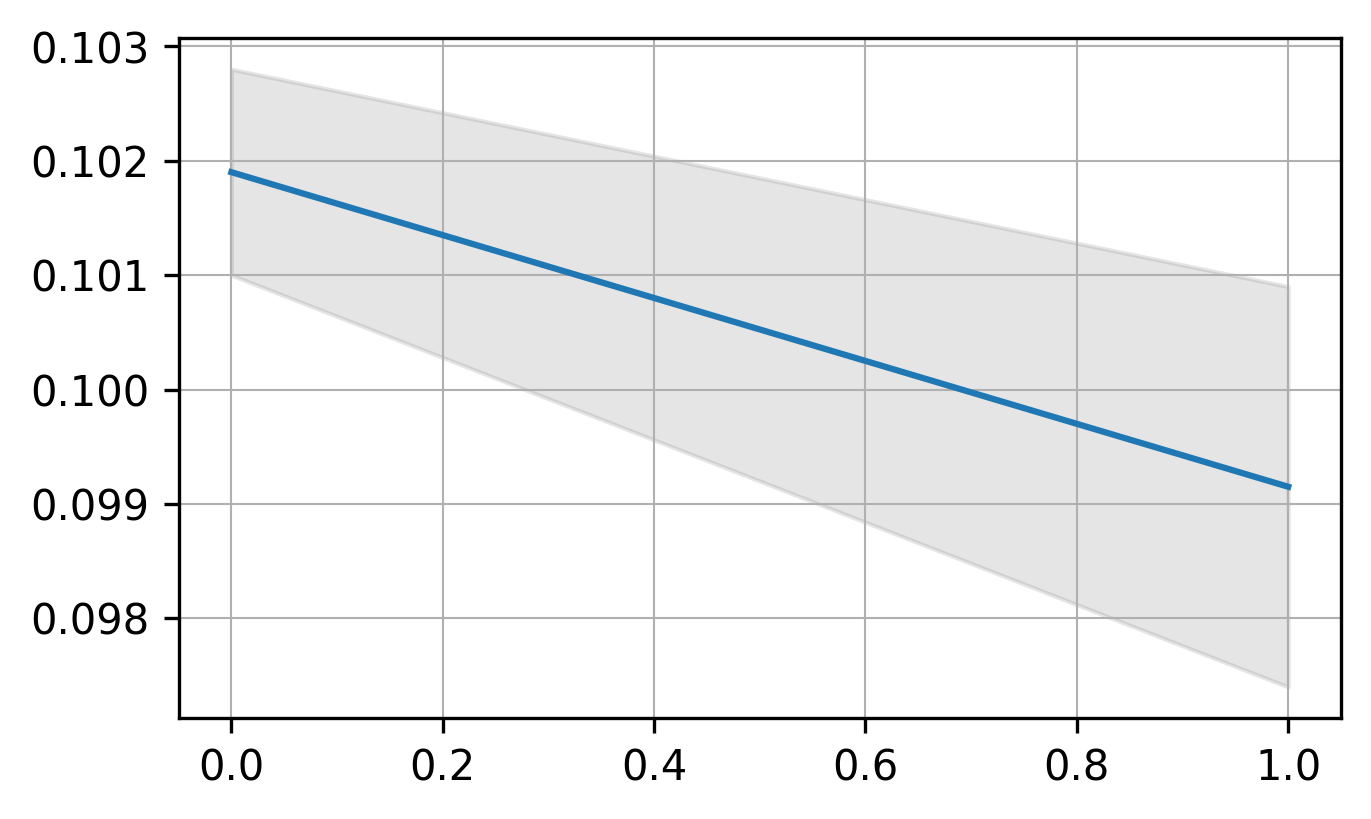

{0: [0.10279999673366547, 0.10100000351667404],
 1: [0.10090000182390213, 0.09740000218153]}

In [27]:
# model_type, dataset_type, partitioning_type, n_clients, alpha, epochs, lrate=0.003
#run_multi_experiment("nn", "MNIST", "hetero-dir", 2, np.arange(0.5, 1.5, 0.5).tolist(), 2, lrate=0.3)
run_multi_experiment("cnn", "MNIST", "hetero-dir", 2, np.arange(0.5, 1.5, 0.5).tolist(), 2, lrate=0.3)
#run_multi_experiment("nn", "CIFAR10", "hetero-dir", 2, np.arange(0.5, 1.5, 0.5).tolist(), 2, lrate=0.3)
#run_multi_experiment("cnn", "CIFAR10", "hetero-dir", 2, np.arange(0.5, 1.5, 0.5).tolist(), 2, lrate=0.3)

313/313 [==============================] - 3s 10ms/step - loss: 9.6709 - accuracy: 0.1000


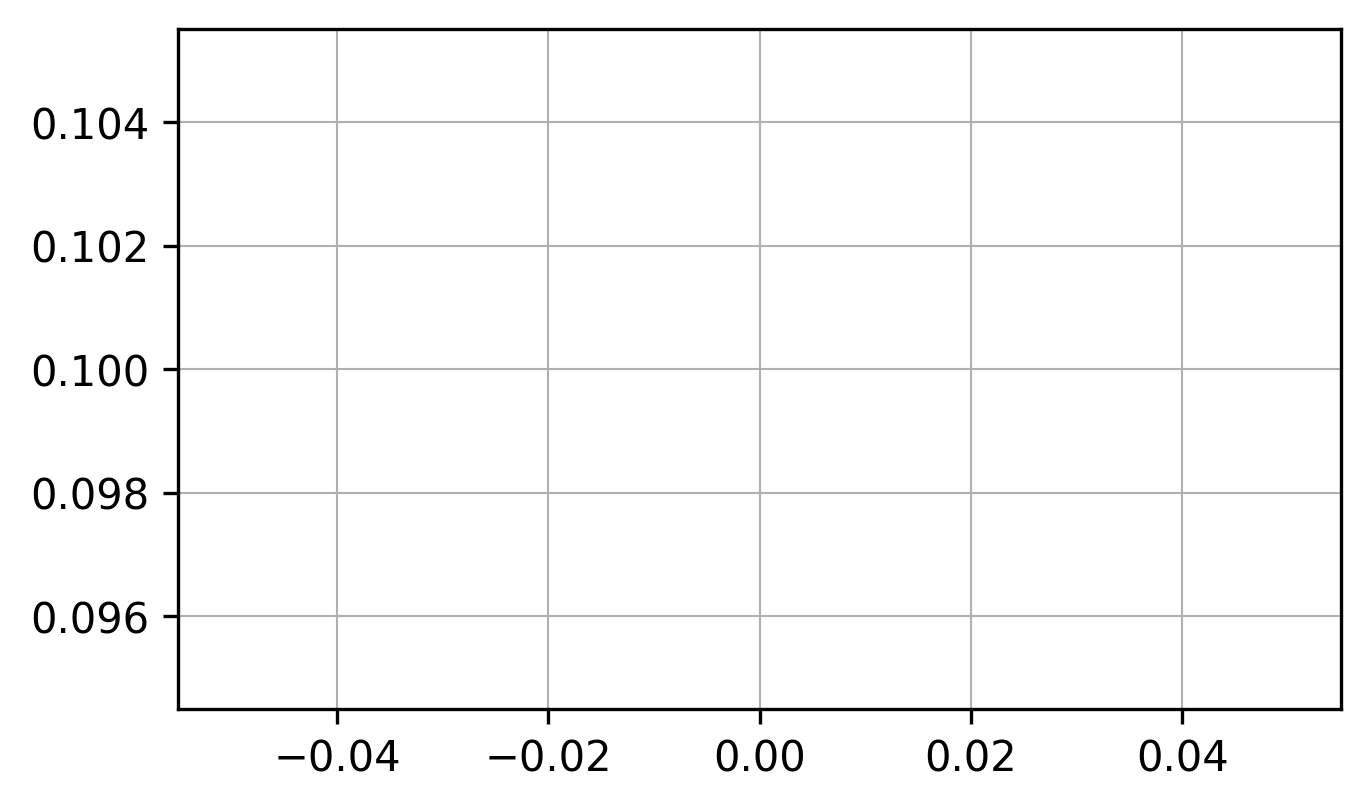

{0: [0.10000000149011612, 0.10000000149011612]}

In [45]:
run_multi_experiment("cnn", "CIFAR10", "hetero-dir", 2, np.arange(0.5, 1.0, 0.5).tolist(), 1, lrate=0.3)

313/313 [==============================] - 1s 2ms/step - loss: 3.7373 - accuracy: 0.1010


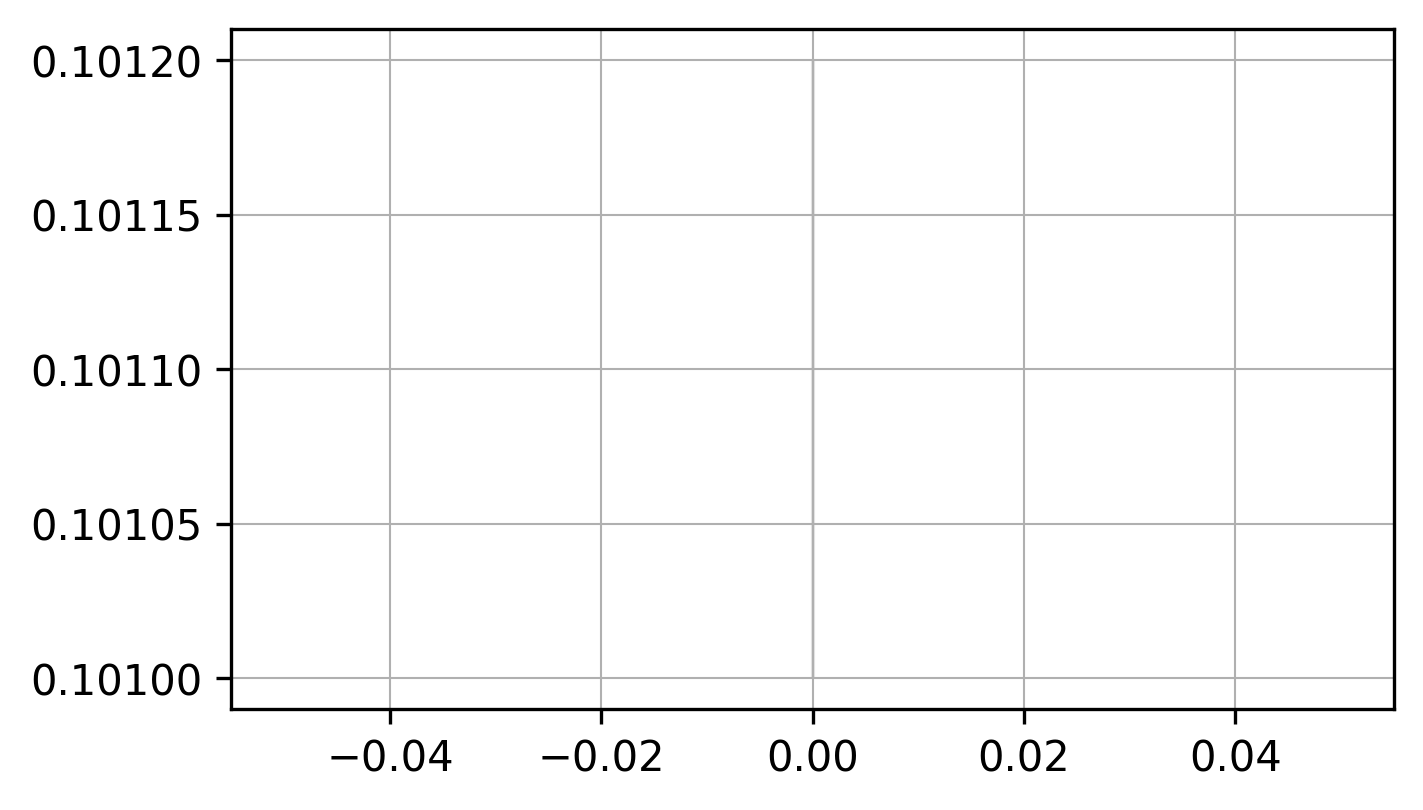

{0: [0.10119999945163727, 0.10100000351667404]}

In [59]:
run_multi_experiment("nn", "MNIST", "hetero-dir", 2, np.arange(0.5, 1.0, 0.5).tolist(), 1, lrate=0.3)

In [73]:
train, test = get_data("MNIST")
subset_map = partition_hetero_dir(train, 2, 0.5) 

subset_0_data = train[0][subset_map[0]]
subset_0_targets = train[1][subset_map[0]]

type(subset_0_data) 
subset_0_data.shape
type(subset_0_targets)
subset_0_targets.shape

(34093,)

In [ ]:
dataset_loaders = {
    "MNIST": mnist.load_data,
    "CIFAR10": cifar10.load_data,
}

dataset_type = "MNISt"
try:
    train, test = dataset_loaders[dataset_type]
except KeyError:
    raise ValueError(f"Invalid mode: {dataset_type}")

In [ ]:
[0.670199990272522,
 0.8228999972343445,
 0.7373999953269958,
 0.7164000272750854,
 0.6353999972343445,
 0.8159999847412109,
 0.661300003528595,
 0.6909999847412109,
 0.8111000061035156,
 0.676800012588501]